In [20]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader



In [21]:
#사용 변수 정의
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

INPUT_LEN = 288
OUTPUT_LEN = 36

BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3

In [22]:
#GPU 사용 가능하면 GPU를 사용, 그렇지 않으면 CPU 사용
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


##1. 데이터 불러오기

In [23]:
# 로컬 실행용 데이터 불러오기
# 이 노트북 파일과 같은 폴더에 AZT1D.csv를 두면 그대로 실행됩니다.
csv_path = r"C:\Users\user\Desktop\200OK-main\AZT1D.csv"
df = pd.read_csv(csv_path)

SMALL_DATA_TEST = True

if SMALL_DATA_TEST: #sanity checker
    selected_ids = df["id"].unique()[:20]
    df = df[df["id"].isin(selected_ids)].copy()
    print("Small dataset test")
    print("ID:", selected_ids)
    print("df shape:", df.shape)
else:
    print("Full dataset mode")

print("Data shape:", df.shape)
print(df.head())

Small dataset test
ID: [ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21]
df shape: (247006, 37)
Data shape: (247006, 37)
     CGM   age  air_temp  basal  bolus  calories_burned  carbs cgm_device  \
0  151.0  65.0       NaN    NaN    NaN              NaN    NaN  Dexcom G6   
1  152.0  65.0       NaN    NaN    NaN              NaN    NaN  Dexcom G6   
2  156.0  65.0       NaN    NaN    NaN              NaN    NaN  Dexcom G6   
3  158.0  65.0       NaN    NaN    NaN              NaN    NaN  Dexcom G6   
4  160.0  65.0       NaN    NaN    NaN              NaN    NaN  Dexcom G6   

  misc_notes                 date  ...  workout_duration  workout_intensity  \
0        NaN  2023-12-08 00:05:00  ...               NaN                NaN   
1        NaN  2023-12-08 00:10:00  ...               NaN                NaN   
2        NaN  2023-12-08 00:15:00  ...               NaN                NaN   
3        NaN  2023-12-08 00:20:00  ...               NaN                NaN   
4        

##2. 데이터 전처리

In [24]:
#df["time"] = pd.to_datetime(df["time"]) #time 컬럼 datetime 형식으로 변환
#df = df[["id", "time", "gl"]].copy() #사용할 컬럼 골라내기
#df = df.dropna(subset=["id", "time", "gl"]) #결측치 제거
#df = df.sort_values(["id", "time"]).reset_index(drop=True) #개인 ID별, 시간순으로 정렬

df = df.rename(columns={ #기존 구조 유지를 위해 column name 재설정
    "date": "time",
    "CGM": "gl"
})

df["time"] = pd.to_datetime(df["time"])

df = df[["id", "time", "gl", "carbs", "bolus", "basal"]].copy()
df = df.dropna(subset=["id", "time", "gl"])

df["carbs"] = df["carbs"].fillna(0)
df["bolus"] = df["bolus"].fillna(0)
df["basal"] = df.groupby("id")["basal"].ffill().fillna(0)

df = df.sort_values(["id", "time"]).reset_index(drop=True)

#glucose 데이터 정규화
scaler = StandardScaler()
df["gl_scaled"] = scaler.fit_transform(df[["gl"]])

#시간대 feature 추가
df["hour"] = df["time"].dt.hour + df["time"].dt.minute / 60
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

#혈당 변화량과 꺾임 정도 feature 추가
df["gl_diff"] = df.groupby("id")["gl_scaled"].diff().fillna(0)
df["gl_accel"] = df.groupby("id")["gl_diff"].diff().fillna(0)

FEATURE_COLS = [
    "gl_scaled",
    "gl_diff",
    "gl_accel",
    "hour_sin",
    "hour_cos",
    "carbs",
    "bolus",
    "basal"
]

print("사용 feature:", FEATURE_COLS)
print(df.head())


사용 feature: ['gl_scaled', 'gl_diff', 'gl_accel', 'hour_sin', 'hour_cos', 'carbs', 'bolus', 'basal']
   id                time     gl  carbs  bolus  basal  gl_scaled      hour  \
0   1 2023-12-08 00:05:00  151.0    0.0    0.0    0.0   0.098982  0.083333   
1   1 2023-12-08 00:10:00  152.0    0.0    0.0    0.0   0.119848  0.166667   
2   1 2023-12-08 00:15:00  156.0    0.0    0.0    0.0   0.203312  0.250000   
3   1 2023-12-08 00:20:00  158.0    0.0    0.0    0.0   0.245044  0.333333   
4   1 2023-12-08 00:25:00  160.0    0.0    0.0    0.0   0.286776  0.416667   

   hour_sin  hour_cos   gl_diff  gl_accel  
0  0.021815  0.999762  0.000000  0.000000  
1  0.043619  0.999048  0.020866  0.020866  
2  0.065403  0.997859  0.083464  0.062598  
3  0.087156  0.996195  0.041732 -0.041732  
4  0.108867  0.994056  0.041732  0.000000  


##3. 원본 데이터셋 가공

In [25]:
def make_sliding_windows(df, input_len=288, output_len=36, feature_cols=None, stride=3):  #메모리 이슈로 15분으로 학습
    X_list = []
    y_list = []

    if feature_cols is None:
        feature_cols = ["gl_scaled"]

    for pid, group in df.groupby("id"):
        group = group.sort_values("time")

        features = group[feature_cols].to_numpy(dtype=np.float32)
        target = group["gl_scaled"].to_numpy(dtype=np.float32)

        if len(group) < input_len + output_len:
            continue

        for i in range(0, len(group) - input_len - output_len + 1, stride):
            x = features[i : i + input_len]
            y = target[i + input_len : i + input_len + output_len]

            X_list.append(x)
            y_list.append(y)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    return X, y

X, y = make_sliding_windows(
    df,
    input_len=INPUT_LEN,
    output_len=OUTPUT_LEN,
    feature_cols=FEATURE_COLS,
    stride=3  # 3 * 5분 = 15분마다 window 생성
)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (78710, 288, 8)
y shape: (78710, 36)


##4. Train / Validation / Test 분리

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

##5. Torch Dataset, DataLoader

In [27]:
#Dataset 코드
class CGMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CGMDataset(X_train, y_train)
val_dataset = CGMDataset(X_val, y_val)
test_dataset = CGMDataset(X_test, y_test)

#DataLoader 코드
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#batch 예시
for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([64, 288, 8])
torch.Size([64, 36])


##6. Encoder GRU

In [28]:
class EncoderGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, x):
        outputs, hidden = self.gru(x)
        return hidden

##7. Decoder GRU

In [29]:
class DecoderGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, hidden):
        output, hidden = self.gru(x, hidden)
        pred = self.fc(output)
        return pred, hidden

##8. Seq2Seq GRU 모델


In [30]:
class Seq2SeqGRU(nn.Module):
    def __init__(
        self,
        encoder_input_dim=5,
        decoder_input_dim=1,
        hidden_dim=64,
        num_layers=2,
        output_len=36,
        dropout=0.2
    ):
        super().__init__()

        self.output_len = output_len

        self.encoder = EncoderGRU(
            input_dim=encoder_input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout
        )

        self.decoder = DecoderGRU(
            input_dim=decoder_input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout
        )

    def forward(self, src, target=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)

        hidden = self.encoder(src)

        #decoder 첫 입력은 마지막 시점의 gl_scaled 값만 사용
        decoder_input = src[:, -1:, 0:1]

        outputs = []

        for t in range(self.output_len):
            pred, hidden = self.decoder(decoder_input, hidden)

            outputs.append(pred.squeeze(1))

            use_teacher_forcing = (
                target is not None and random.random() < teacher_forcing_ratio
            )

            if use_teacher_forcing:
                decoder_input = target[:, t].view(batch_size, 1, 1)
            else:
                decoder_input = pred

        outputs = torch.cat(outputs, dim=1)

        return outputs


##9. 모델 생성 및 학습 사전준비



In [31]:
model = Seq2SeqGRU(
    encoder_input_dim=len(FEATURE_COLS),
    decoder_input_dim=1,
    hidden_dim=64,
    num_layers=2,
    output_len=OUTPUT_LEN,
    dropout=0.2
).to(DEVICE)

criterion = nn.HuberLoss(delta=1.0)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

#criterion = nn.MSELoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(
            X_batch,
            target=y_batch,
            teacher_forcing_ratio=0.5
        )

        loss = criterion(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(train_loader.dataset)

    return avg_loss


##10. 검증 및 테스트

In [32]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(
                X_batch,
                target=None,
                teacher_forcing_ratio=0.0
            )

            loss = criterion(pred, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(data_loader.dataset)

    return avg_loss

##11. Epoch별 예측 결과 저장 준비


In [33]:
# Epoch별 예측 결과 저장 준비

RESULT_DIR = "./epoch_results"
os.makedirs(RESULT_DIR, exist_ok=True)

EPOCH_LOSS_CSV = os.path.join(RESULT_DIR, "epoch_losses.csv")
best_model_path = os.path.join(RESULT_DIR, "best_seq2seq_gru.pt")

SAMPLE_IDX_FOR_EPOCH = 0

# 같은 학습 루프를 다시 실행할 때 이전 loss 기록이 섞이지 않도록 삭제
if os.path.exists(EPOCH_LOSS_CSV):
    os.remove(EPOCH_LOSS_CSV)

# 비교용 실제 y_test 값을 미리 mg/dL 단위로 복원
y_test_original_for_epoch = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(y_test.shape)

# Epoch별 예측 결과 메모리에 저장
epoch_prediction_history = []


def predict_one_sample_original(model, X_test, scaler, sample_idx, device):
    """test sample 하나에 대한 미래 3시간 예측값을 mg/dL 단위로 반환"""
    model.eval()

    with torch.no_grad():
        x_sample = torch.tensor(
            X_test[sample_idx:sample_idx + 1],
            dtype=torch.float32
        ).to(device)

        pred_scaled = model(
            x_sample,
            target=None,
            teacher_forcing_ratio=0.0
        )

        pred_scaled = pred_scaled.cpu().numpy()

    pred_original = scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    return pred_original


##11. 모델 학습


In [34]:
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    # 1. best model 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

    # 2. epoch별 loss 저장
    loss_df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "val_loss": val_losses
    })
    loss_df.to_csv(EPOCH_LOSS_CSV, index=False)

    # 3. 같은 test sample에 대한 epoch별 예측 결과를 mg/dL 단위로 바로 저장
    pred_epoch_original = predict_one_sample_original(
        model=model,
        X_test=X_test,
        scaler=scaler,
        sample_idx=SAMPLE_IDX_FOR_EPOCH,
        device=DEVICE
    )

    true_epoch_original = y_test_original_for_epoch[SAMPLE_IDX_FOR_EPOCH]
    minute_axis = np.arange(1, OUTPUT_LEN + 1) * 5

    epoch_prediction_history.append({
        "epoch": epoch,
        "minute": minute_axis,
        "true_glucose": true_epoch_original,
        "predicted_glucose": pred_epoch_original,
        "abs_error": np.abs(true_epoch_original - pred_epoch_original)
    })

    print(f"Epoch {epoch} prediction stored in memory.")




Epoch [1/10] Train Loss: 0.037540 Val Loss: 0.390576
Best model saved.
Epoch 1 prediction stored in memory.
Epoch [2/10] Train Loss: 0.025926 Val Loss: 0.253564
Best model saved.
Epoch 2 prediction stored in memory.
Epoch [3/10] Train Loss: 0.024195 Val Loss: 0.268027
Epoch 3 prediction stored in memory.
Epoch [4/10] Train Loss: 0.024000 Val Loss: 0.273789
Epoch 4 prediction stored in memory.
Epoch [5/10] Train Loss: 0.022952 Val Loss: 0.278619
Epoch 5 prediction stored in memory.
Epoch [6/10] Train Loss: 0.024154 Val Loss: 0.370127
Epoch 6 prediction stored in memory.
Epoch [7/10] Train Loss: 0.023078 Val Loss: 0.339823
Epoch 7 prediction stored in memory.
Epoch [8/10] Train Loss: 0.022850 Val Loss: 0.259775
Epoch 8 prediction stored in memory.
Epoch [9/10] Train Loss: 0.022366 Val Loss: 0.244861
Best model saved.
Epoch 9 prediction stored in memory.
Epoch [10/10] Train Loss: 0.021655 Val Loss: 0.239530
Best model saved.
Epoch 10 prediction stored in memory.


##12. 테스트 평가

In [35]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)

        pred = model(
            X_batch,
            target=None,
            teacher_forcing_ratio=0.0
        )

        all_preds.append(pred.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

##13. 정규화 복원 및 평가

In [36]:
preds_original = scaler.inverse_transform(
    all_preds.reshape(-1, 1)
).reshape(all_preds.shape)

targets_original = scaler.inverse_transform(
    all_targets.reshape(-1, 1)
).reshape(all_targets.shape)

#MAE와 RMSE 사용
MAE = mean_absolute_error(
    targets_original.reshape(-1),
    preds_original.reshape(-1)
)

MSE = mean_squared_error( 
    targets_original.reshape(-1),
    preds_original.reshape(-1)
    )

RMSE = np.sqrt(
    mean_squared_error(
        targets_original.reshape(-1),
        preds_original.reshape(-1)
    )
)

print(f"Test MAE: {MAE:.2f} mg/dL")
print(f"Test MSE: {MSE:.2f} mg/dL")
print(f"Test RMSE: {RMSE:.2f} mg/dL")
pred_list = preds_original[0].tolist()
print(pred_list)

Test MAE: 24.89 mg/dL
Test MSE: 1275.46 mg/dL
Test RMSE: 35.71 mg/dL
[164.74319458007812, 164.10231018066406, 162.94100952148438, 161.5706787109375, 160.02862548828125, 158.35508728027344, 156.56993103027344, 154.69964599609375, 152.77218627929688, 150.8133087158203, 148.8455810546875, 146.8882293701172, 144.95726013183594, 143.06578063964844, 141.22425842285156, 139.44100952148438, 137.72250366210938, 136.07379150390625, 134.49871826171875, 133.00013732910156, 131.58016967773438, 130.24024963378906, 128.9812774658203, 127.80371856689453, 126.70757293701172, 125.6925277709961, 124.7579116821289, 123.90279388427734, 123.1259536743164, 122.42595672607422, 121.8011245727539, 121.2496109008789, 120.76939392089844, 120.3582992553711, 120.01402282714844, 119.73414611816406]


In [37]:
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = [
        "Malgun Gothic",      # Windows
        "AppleGothic",        # Mac
        "NanumGothic",        # Linux / Colab
        "Noto Sans CJK KR"
    ]
    available_fonts = {f.name for f in fm.fontManager.ttflist}

    for font in candidates:
        if font in available_fonts:
            plt.rcParams["font.family"] = font
            break

    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

##14. 3시간 후 그래프 출력

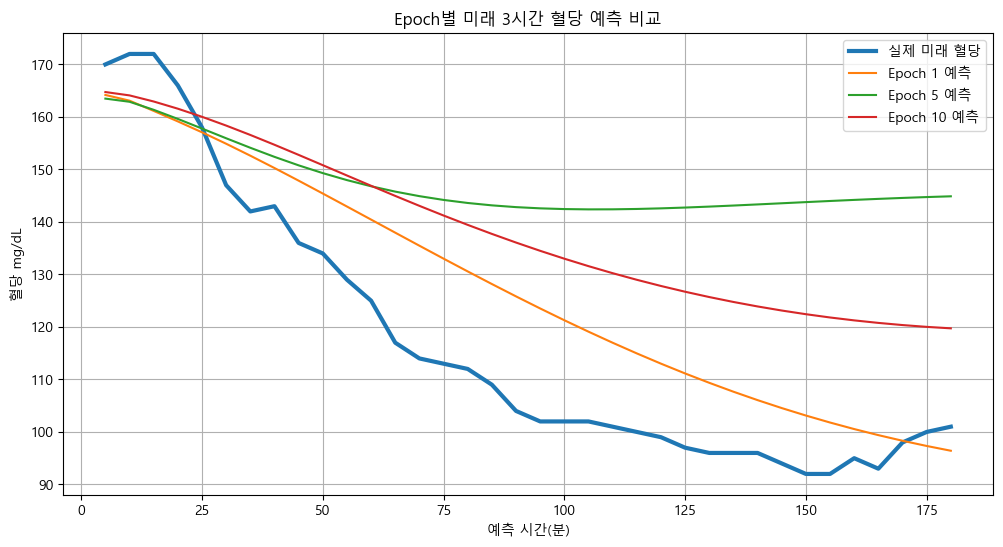

In [38]:
# Epoch별 예측 결과 확인
# EPOCHS 중간 과정 선별 확인

if EPOCHS <= 5:
    selected_epochs = list(range(1, EPOCHS + 1))
else:
    selected_epochs = sorted(set([1, max(1, EPOCHS // 2), EPOCHS]))

plt.figure(figsize=(12, 6))


first_result = epoch_prediction_history[0]
plt.plot(
    first_result["minute"],
    first_result["true_glucose"],
    label="실제 미래 혈당",
    linewidth=3
)

for result in epoch_prediction_history:
    ep = result["epoch"]

    if ep not in selected_epochs:
        continue

    plt.plot(
        result["minute"],
        result["predicted_glucose"],
        label=f"Epoch {ep} 예측"
    )

plt.xlabel("예측 시간(분)")
plt.ylabel("혈당 mg/dL")
plt.title("Epoch별 미래 3시간 혈당 예측 비교")
plt.legend()
plt.grid(True)
plt.show()


